In [ ]:
# Metadata exploration: distributions, correlations, outliers, and grouped trends
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Load metadata
METADATA_FILE = "../data/raw/metadata.csv"
df = pd.read_csv(METADATA_FILE)

# Convert relevant columns to numeric
metrics = [
    'viewCount', 'likeCount', 'commentCount', 'duration_sec',
    'channelViewCount', 'subscriberCount', 'channelVideoCount'
]
df[metrics] = df[metrics].apply(pd.to_numeric, errors='coerce')

In [29]:
df

,videoId,videoUrl,title,publishDate,channelTitle,channelId,tags,categoryId,liveBroadcastContent,defaultAudioLanguage,duration_sec,viewCount,likeCount,commentCount,channelViewCount,subscriberCount,hiddenSubscriberCount,channelVideoCount
0,wL8qX260NTk,https://www.youtube.com/watch?v=wL8qX260NTk,"Chloe Caron on Artificial Intelligence, Data a...",2024-05-04T12:29:02Z,The Nonstop Podcast,UCXDIgPEOF0jq_LVy-3Ialug,[],22.0,none,en,2204.0,64.0,3.0,0.0,1.165000e+04,60.0,False,72.0
1,I61WP51sSsc,https://www.youtube.com/watch?v=I61WP51sSsc,Episode 13 | Artificial Intelligence for Busin...,2025-06-03T15:00:06Z,Behind The Work Show,UCm1mQaBMIpEdUAR9ImV_RMw,[],22.0,none,NaN,3266.0,10.0,1.0,0.0,4.490000e+02,28.0,False,17.0
2,bMmAI0neLaY,https://www.youtube.com/watch?v=bMmAI0neLaY,Singapore Roundtable - Asia’s Perspective on A...,2024-12-06T06:21:10Z,AI Safety Asia,UCQBPcRCiClcc51-lZGnNSmg,[],22.0,none,NaN,5376.0,96.0,0.0,0.0,1.042000e+03,70.0,False,13.0
3,t58X0md283Y,https://www.youtube.com/watch?v=t58X0md283Y,ClueCon 2024 | AI Roundtable,2024-09-03T17:42:34Z,FreeSWITCH,UC0i2xbniNHJQNfPPs_v4T0Q,[],28.0,none,en,3483.0,128.0,2.0,0.0,4.811580e+05,3730.0,False,821.0
4,o8NiE3XMPrM,https://www.youtube.com/watch?v=o8NiE3XMPrM,Google I/O '25 Keynote,2025-05-20T19:05:53Z,Google,UCK8sQmJBp8GCxrOtXWBpyEA,"['AI', 'Tech', 'AI News', 'Artificial Intellig...",28.0,none,en,6996.0,6875161.0,40845.0,0.0,4.628032e+09,13200000.0,False,2332.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26176,cc-ZTaw4Phk,https://www.youtube.com/watch?v=cc-ZTaw4Phk,Well-Being Wisdom Podcast Episode 4 - Well-bei...,2024-10-16T19:53:12Z,University of Texas Health Science Center at S...,UC62Bzdr5j-wKGqODlPIJMrQ,"['UT Health Science Center at San Antonio', 'T...",27.0,none,en,1920.0,26.0,0.0,0.0,1.144563e+06,5630.0,False,1028.0
26177,eRCSRe-8pKo,https://www.youtube.com/watch?v=eRCSRe-8pKo,The Most Creative Employee Rewards & Recogniti...,2024-06-13T19:00:06Z,Steward Your Business,UCN-UrWHGxEu4-NpT0mAxAZw,"['employee appreciation', 'employee morale', '...",22.0,none,en-US,3232.0,14.0,1.0,0.0,1.227800e+04,111.0,False,369.0
26178,iTDx12l0T3M,https://www.youtube.com/watch?v=iTDx12l0T3M,Let's Talk About Teacher Wellness,2025-05-22T18:44:22Z,Kenya Women Teachers Association (KEWOTA),UCsaJEbcxtTg1h9mHp_xivbw,[],22.0,none,NaN,1985.0,221.0,0.0,2.0,5.233000e+03,124.0,False,44.0
26179,YJ9B_UfTFMw,https://www.youtube.com/watch?v=YJ9B_UfTFMw,The Power of Vulnerability & Faith,2025-02-17T11:00:48Z,Leave Your Legacy Show,UCGqjUaGoTvKAYTdoAwW7RPg,[],22.0,none,en,3908.0,109.0,3.0,0.0,3.589900e+04,288.0,False,133.0


In [30]:
# Basic info
print("\n--- Basic Info ---")
print(df.info())


--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26181 entries, 0 to 26180
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   videoId                26181 non-null  object 
 1   videoUrl               26181 non-null  object 
 2   title                  26181 non-null  object 
 3   publishDate            26181 non-null  object 
 4   channelTitle           26181 non-null  object 
 5   channelId              26181 non-null  object 
 6   tags                   26181 non-null  object 
 7   categoryId             26181 non-null  float64
 8   liveBroadcastContent   26181 non-null  object 
 9   defaultAudioLanguage   16928 non-null  object 
 10  duration_sec           26181 non-null  float64
 11  viewCount              26181 non-null  float64
 12  likeCount              26181 non-null  float64
 13  commentCount           26181 non-null  float64
 14  channelViewCount       26181 non-n

In [31]:
# Check missing values
print("\n--- Missing Values ---")
print(df[metrics].isnull().sum())


--- Missing Values ---
viewCount            0
likeCount            0
commentCount         0
duration_sec         0
channelViewCount     0
subscriberCount      0
channelVideoCount    0
dtype: int64


In [32]:
# Descriptive statistics
print("\n--- Descriptive Statistics ---")
print(df[metrics].describe())


--- Descriptive Statistics ---
          viewCount      likeCount   commentCount  duration_sec  \
count  2.618100e+04   26181.000000   26181.000000  26181.000000   
mean   1.965895e+05    3366.464956     417.015775   3453.049425   
std    2.672299e+06   19643.621187    2941.236789   1263.518386   
min    0.000000e+00       0.000000       0.000000   1800.000000   
25%    2.900000e+01       0.000000       0.000000   2436.000000   
50%    1.290000e+02       4.000000       0.000000   3232.000000   
75%    6.031000e+03     187.000000      22.000000   4116.000000   
max    1.746352e+08  848054.000000  180462.000000   7200.000000   

       channelViewCount  subscriberCount  channelVideoCount  
count      2.618100e+04     2.618100e+04       26181.000000  
mean       1.961172e+08     5.195941e+05        2089.182537  
std        1.896991e+09     2.697980e+06       13579.170141  
min        0.000000e+00     0.000000e+00           1.000000  
25%        1.450400e+04     1.680000e+02          82.0

In [33]:
# Outlier Detection using IQR
print("\n--- Outlier Counts (Above Q3 + 1.5*IQR) ---")
for col in metrics:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[df[col] > Q3 + 1.5 * IQR]
    print(f"{col}: {len(outliers)} outliers")


--- Outlier Counts (Above Q3 + 1.5*IQR) ---
viewCount: 5535 outliers
likeCount: 5452 outliers
commentCount: 5355 outliers
duration_sec: 575 outliers
channelViewCount: 5133 outliers
subscriberCount: 5105 outliers
channelVideoCount: 3128 outliers


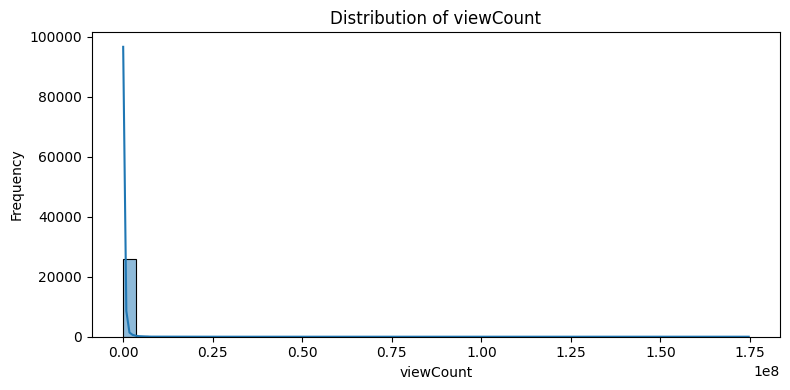

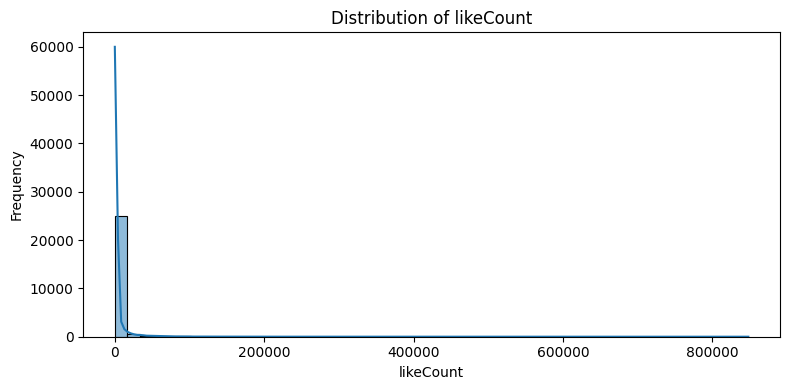

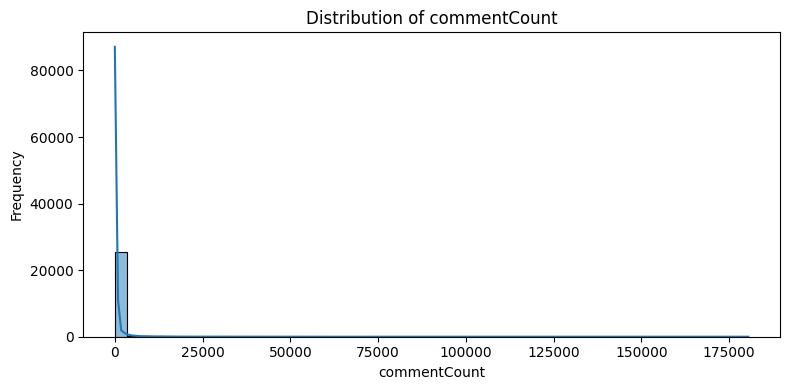

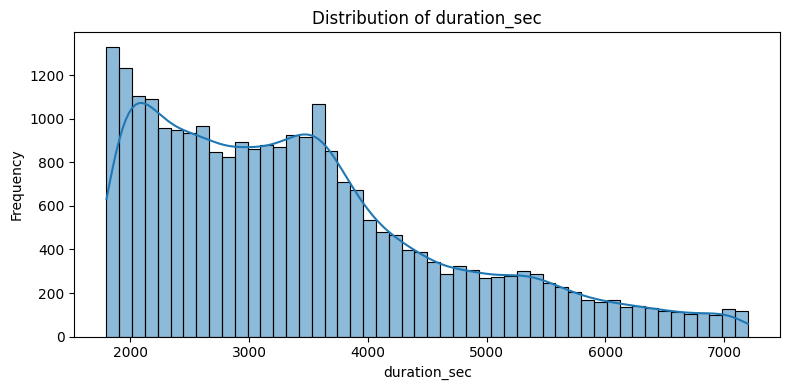

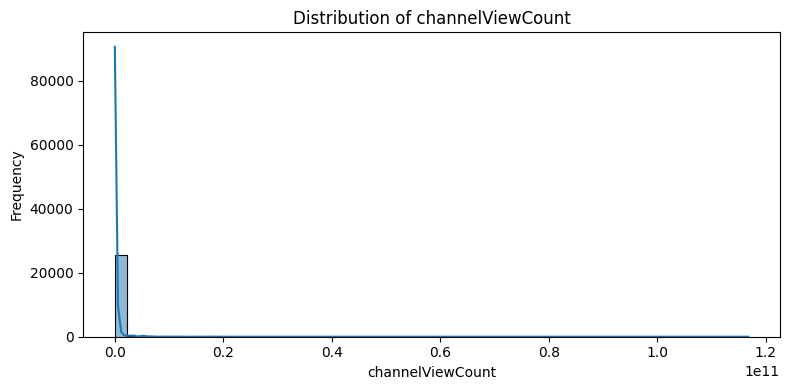

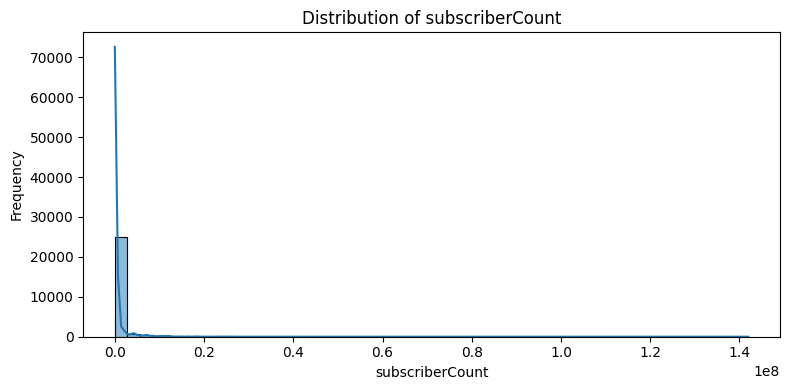

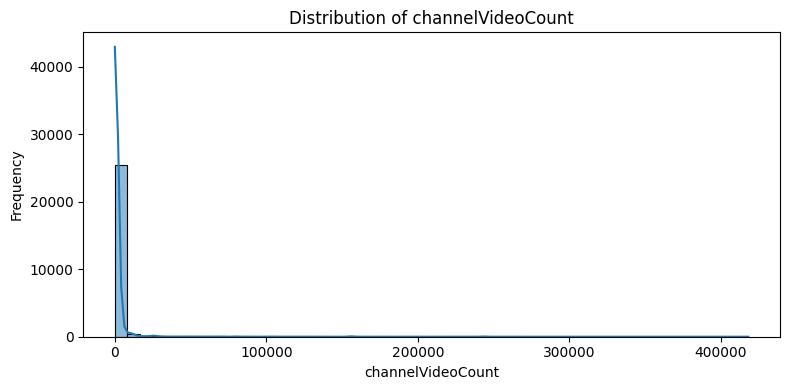

In [34]:
# Distributions of each metric
for col in metrics:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

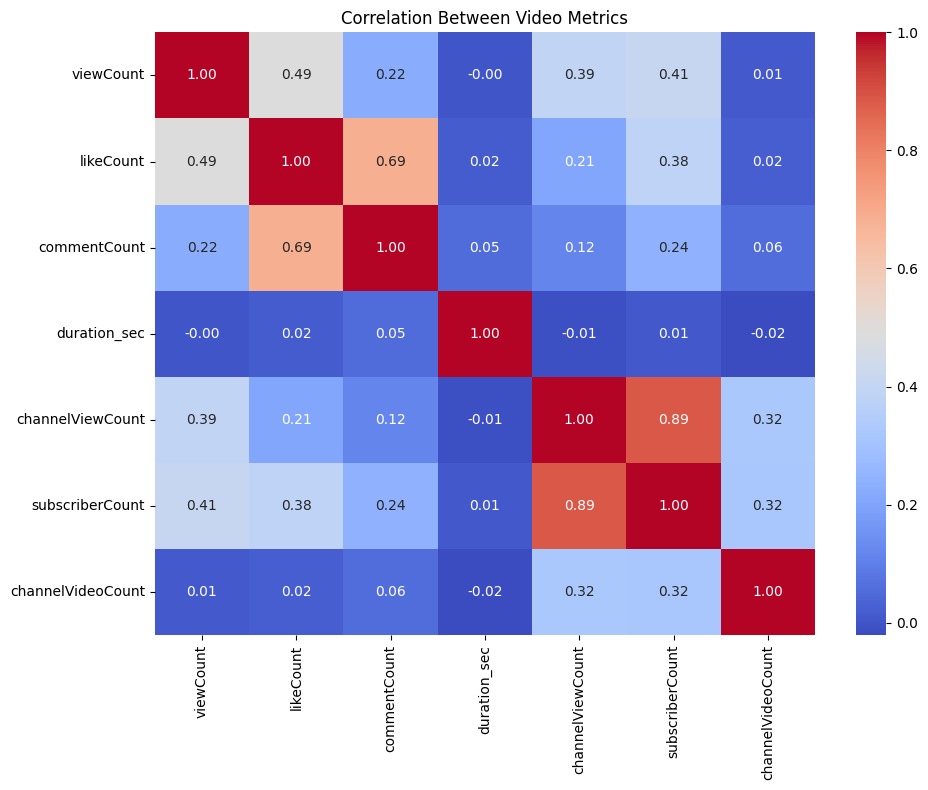

In [35]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[metrics].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Video Metrics")
plt.tight_layout()
plt.show()

In [36]:
# Channel-level statistics
channel_stats = df.groupby("channelTitle")[metrics].mean().sort_values(by="viewCount", ascending=False).head(20)
print("\n--- Top 20 Channels by Average View Count ---")
print(channel_stats)


--- Top 20 Channels by Average View Count ---
                                        viewCount      likeCount  \
channelTitle                                                       
Vlad and Niki                        1.511232e+08  290150.000000   
Ms Rachel - Toddler Learning Videos  1.294812e+08  237813.166667   
✿ Kids Diana Show                    1.020584e+08  140985.000000   
Bluey - Official Channel             5.361093e+07   81537.000000   
Like Nastya                          4.677525e+07   70255.000000   
Dhar Mann Studios                    3.678799e+07  419221.000000   
Jordan Matter                        2.697088e+07  262568.000000   
The Wall Street Journal              1.918580e+07  199953.500000   
The Royalty Family                   1.890669e+07  185999.000000   
Goobie and Doobie                    1.694399e+07  735520.000000   
Vania Mania Kids                     1.603946e+07    4348.000000   
Dhruv Rathee                         1.550965e+07  465031.333333   
V

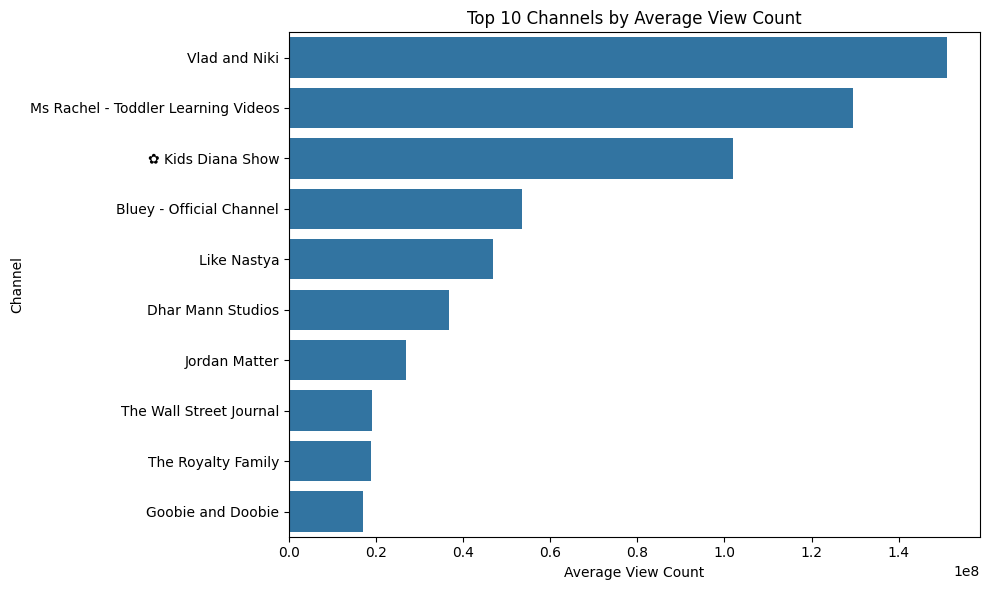

In [37]:
# Barplot: top 10 channels by average views
channel_stats_sorted = channel_stats.sort_values(by="viewCount", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=channel_stats_sorted['viewCount'].head(10), y=channel_stats_sorted.index[:10])
plt.title("Top 10 Channels by Average View Count")
plt.xlabel("Average View Count")
plt.ylabel("Channel")
plt.tight_layout()
plt.show()

In [38]:
# Segmentation by video length buckets
def get_length_bucket(duration):
    if duration < 3600:
        return 'Medium (30-60 min)'
    elif duration < 5400:
        return 'Long (60-90 min)'
    else:
        return 'Very Long (>90 min)'

df['length_bucket'] = df['duration_sec'].apply(get_length_bucket)


--- Stats by Video Length Bucket ---
                         viewCount    likeCount  commentCount  duration_sec  \
length_bucket                                                                 
Long (60-90 min)     158460.321764  2791.565401    386.225262   4295.417994   
Medium (30-60 min)   197191.537180  3259.310902    338.422382   2648.687684   
Very Long (>90 min)  302108.101093  5695.660031   1004.482436   6146.137783   

                     channelViewCount  subscriberCount  channelVideoCount  
length_bucket                                                              
Long (60-90 min)         1.598324e+08    424104.699333        1412.480196  
Medium (30-60 min)       2.113936e+08    525203.578909        2431.369899  
Very Long (>90 min)      2.031457e+08    757799.443404        1856.418813  


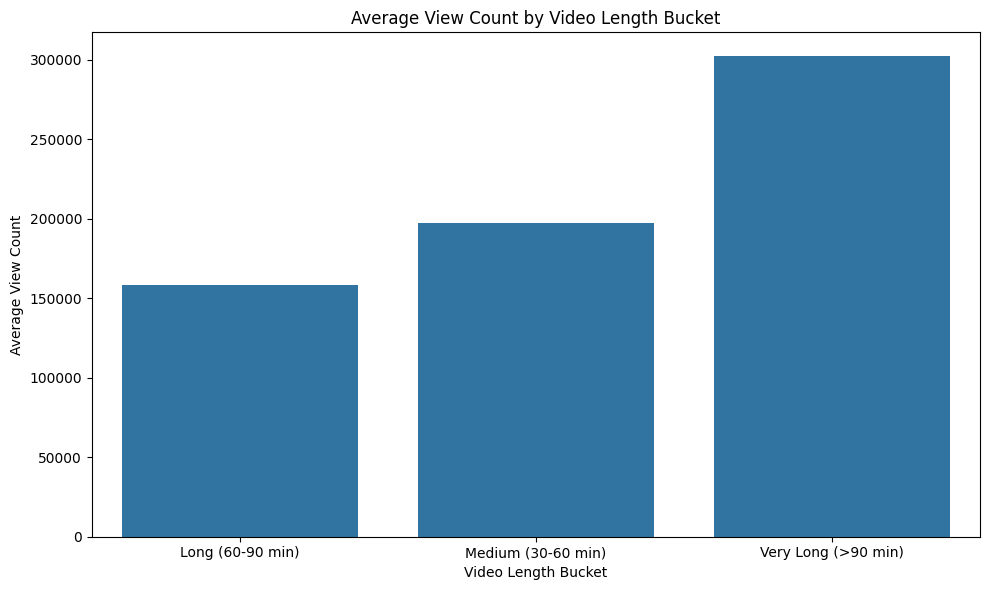

In [39]:
# Compare average metrics across length buckets
bucket_stats = df.groupby("length_bucket")[metrics].mean()
print("\n--- Stats by Video Length Bucket ---")
print(bucket_stats)

plt.figure(figsize=(10, 6))
sns.barplot(x=bucket_stats.index, y=bucket_stats['viewCount'])
plt.title("Average View Count by Video Length Bucket")
plt.xlabel("Video Length Bucket")
plt.ylabel("Average View Count")
plt.tight_layout()
plt.show()

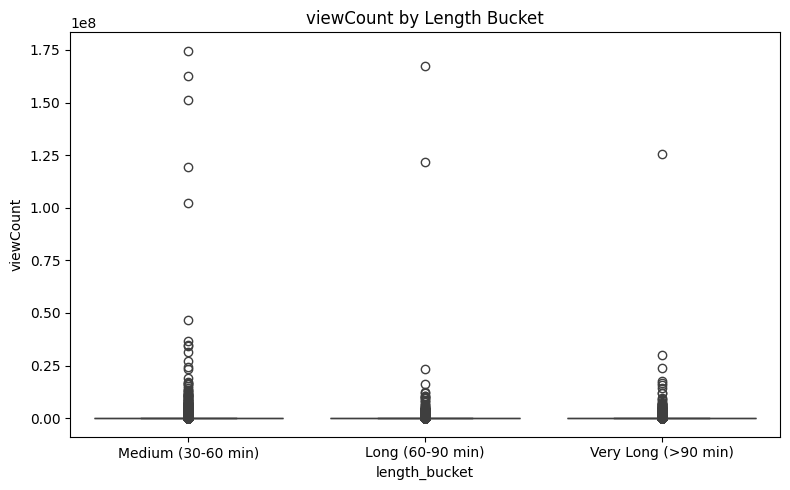

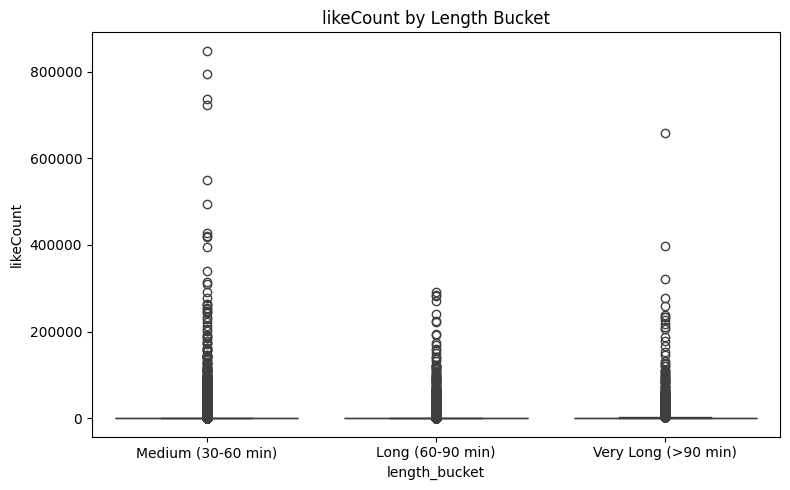

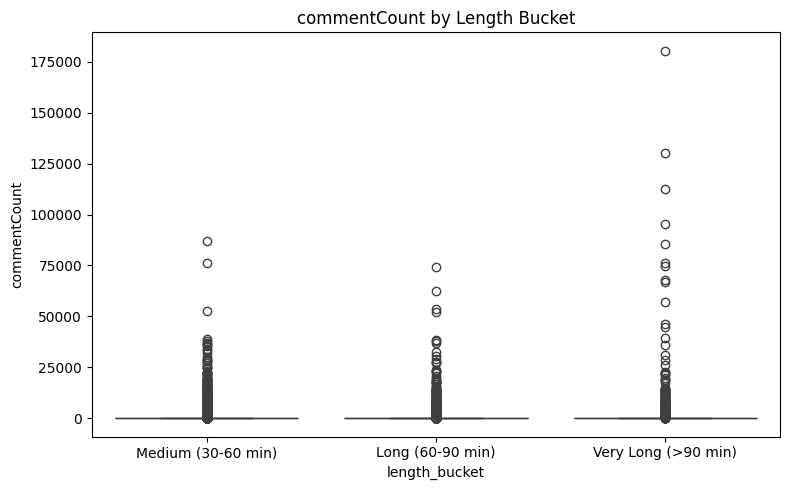

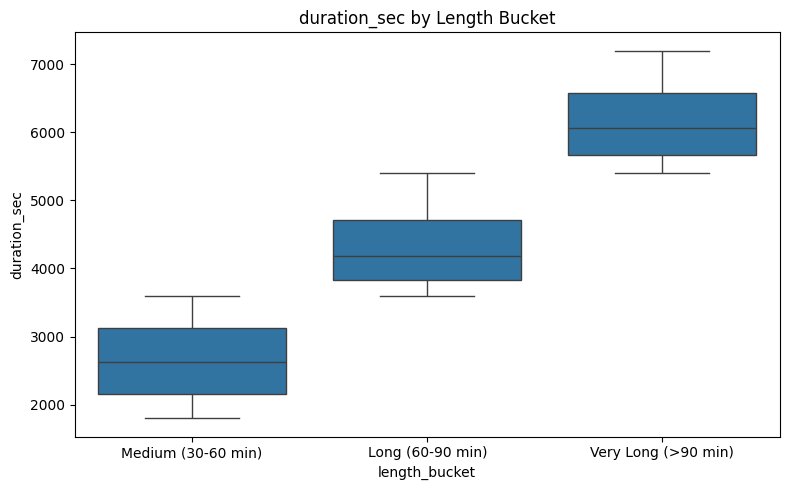

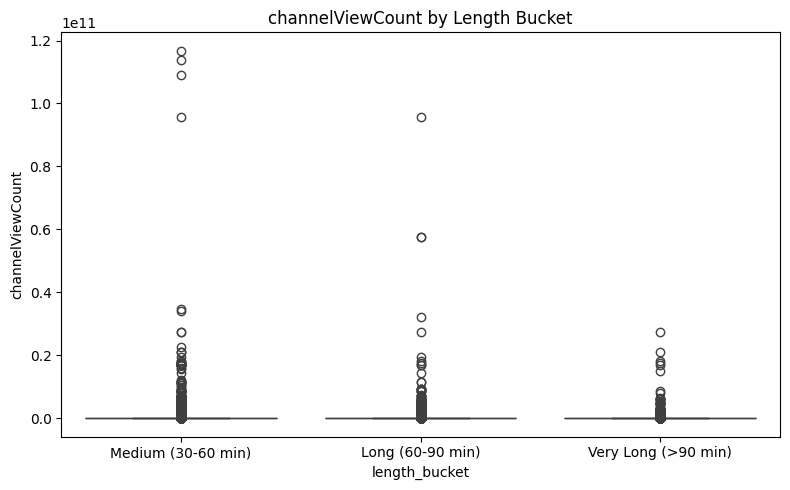

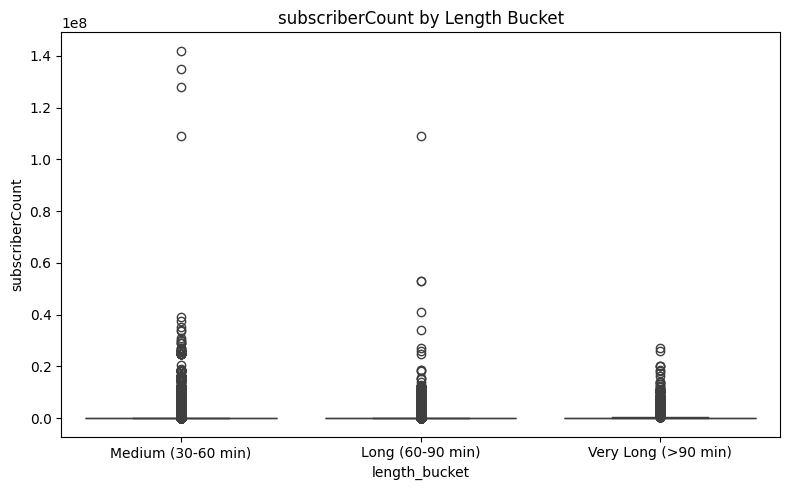

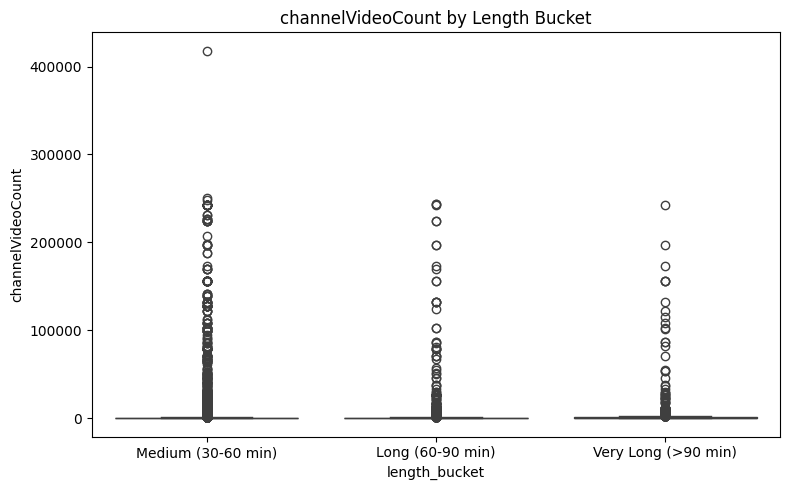

In [40]:
# Grouped trends by metric and length_bucket
for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='length_bucket', y=metric)
    plt.title(f"{metric} by Length Bucket")
    plt.tight_layout()
    plt.show()